# OSHA Workplace Injury & Illness — Exploratory Data Analysis
### A Workplace Safety Analyst Report for Operations & HR Leadership
---
*Data: OSHA ITA Summary Data 2024 | 398,620 U.S. Establishments | Python · Pandas · Matplotlib · Seaborn*

## Section 0 — Business Context

Every year, millions of American workers are injured on the job. The **Occupational Safety and Health Administration (OSHA)** requires establishments with 20 or more employees in high-hazard industries to electronically submit their annual injury and illness summary data — a program called the **Injury Tracking Application (ITA)**. This dataset captures 2024 filings from **398,620 U.S. workplaces**, spanning every state and major industry sector, and includes counts of deaths, lost-work-day cases, restricted-duty cases, and illness types.

As a workplace safety analyst, this report answers six critical questions that matter to an operations VP or HR director: which industries and states carry the highest risk burden, whether company size predicts injury frequency, which injury types are most common and most severe, and which specific companies are repeat offenders. Every finding is translated into a concrete, actionable recommendation — because the goal of safety data is not just measurement, but prevention.

> **Note on data scope:** This file covers a single reporting year (2024). Cross-sectional analysis across 398K+ establishments provides robust industry and geographic benchmarks even without a multi-year time series.

## Section 1 — Data Loading & Profiling

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import logging
import asyncio
import sys
import os
from pathlib import Path

# ── Suppress warnings ──────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
logging.getLogger('tornado').setLevel(logging.ERROR)

# Suppress "Task was destroyed but it is pending" warnings from
# Python 3.14 + ipykernel asyncio loop interactions
if sys.version_info >= (3, 14):
    asyncio.get_event_loop_policy()

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..').resolve()
RAW_DIR    = BASE_DIR / 'data' / 'raw'
CHARTS_DIR = BASE_DIR / 'charts'
OUTPUT_DIR = BASE_DIR / 'outputs'

CHARTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Chart style ────────────────────────────────────────────────────────────────
PRIMARY_BLUE  = '#1B4F72'
ACCENT_ORANGE = '#E67E22'
PALETTE       = sns.color_palette([PRIMARY_BLUE, '#2E86C1', '#85C1E9',
                                   ACCENT_ORANGE, '#F0B27A', '#85929E'])
plt.rcParams.update({
    'figure.dpi':       150,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'font.family':      'sans-serif',
})

print("Libraries loaded. Paths configured.")
print(f"  Python   : {sys.version}")
print(f"  Base dir : {BASE_DIR}")
print(f"  Charts   : {CHARTS_DIR}")
print(f"  Outputs  : {OUTPUT_DIR}")

Libraries loaded. Paths configured.
  Python   : 3.14.0 (v3.14.0:ebf955df7a8, Oct  7 2025, 08:20:14) [Clang 16.0.0 (clang-1600.0.26.6)]
  Base dir : /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA
  Charts   : /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts
  Outputs  : /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/outputs


### 1.1 Load Raw Data

In [28]:
# Load raw CSV — low_memory=False prevents dtype inference warnings on mixed columns
raw_path = RAW_DIR / 'ITA_Summary_Data_2024.csv'
df_raw = pd.read_csv(raw_path, low_memory=False)

print(f"Loaded: {raw_path.name}")
print(f"Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded: ITA_Summary_Data_2024.csv
Shape : 398,620 rows x 32 columns


,id,establishment_name,establishment_id,ein,company_name,street_address,city,state,zip_code,naics_code,...,total_djtr_days,total_injuries,total_skin_disorders,total_respiratory_conditions,total_poisonings,total_hearing_loss,total_other_illnesses,created_timestamp,change_reason,year_filing_for
0,2808362,AristaCare at Meadow Springs,41940,204755042.0,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462,623110,...,32,7,0,0,0,0,0,28FEB25:16:35:00,NaN,2024
1,2587120,AM Braswell Jr. Food Company,41942,580667528.0,AM Braswell Jr. Food Company,226 North Zetterower Avenue,Statesboro,GA,30458,311421,...,69,10,0,0,0,0,1,31JAN25:20:24:00,NaN,2024
2,2575264,"SMM Group Chesapeake, VA",41952,453807558.0,Sims Metal Management,4300 Buell Street,Chesapeake,VA,23324,423930,...,0,1,0,0,0,0,0,29JAN25:14:47:00,NaN,2024


### 1.2 Shape, Column Names & Data Types

In [29]:
print("── Column Names & Data Types ──────────────────────────────")
dtype_df = pd.DataFrame({
    'dtype':    df_raw.dtypes.astype(str),
    'non_null': df_raw.notna().sum(),
    'null_pct': (df_raw.isna().mean() * 100).round(2)
})
print(dtype_df.to_string())

── Column Names & Data Types ──────────────────────────────
                                dtype  non_null  null_pct
id                              int64    398620      0.00
establishment_name             object    398620      0.00
establishment_id                int64    398620      0.00
ein                           float64    355360     10.85
company_name                   object    379082      4.90
street_address                 object    398618      0.00
city                           object    398618      0.00
state                          object    398620      0.00
zip_code                        int64    398620      0.00
naics_code                      int64    398620      0.00
naics_year                      int64    398620      0.00
industry_description           object    371824      6.72
establishment_type            float64    398065      0.14
size                            int64    398620      0.00
annual_average_employees        int64    398620      0.00
total_hours_

### 1.3 Null Value Analysis

In [30]:
null_summary = (
    df_raw.isnull().sum()
    .rename('null_count')
    .to_frame()
    .assign(null_pct=lambda x: (x['null_count'] / len(df_raw) * 100).round(2))
    .query('null_count > 0')
    .sort_values('null_pct', ascending=False)
)
print("Columns with nulls:")
print(null_summary.to_string())
print(f"\nDuplicate rows: {df_raw.duplicated().sum():,}")

Columns with nulls:
                      null_count  null_pct
change_reason             384744     96.52
ein                        43260     10.85
industry_description       26796      6.72
company_name               19538      4.90
establishment_type           555      0.14
street_address                 2      0.00
city                           2      0.00

Duplicate rows: 0


### 1.4 Key Numeric Distributions

In [31]:
key_numerics = [
    'annual_average_employees', 'total_hours_worked',
    'total_injuries', 'total_deaths',
    'total_dafw_cases', 'total_djtr_cases',
    'total_dafw_days', 'total_djtr_days'
]
print("Summary statistics for key numeric columns:")
df_raw[key_numerics].describe().round(2)

Summary statistics for key numeric columns:


,annual_average_employees,total_hours_worked,total_injuries,total_deaths,total_dafw_cases,total_djtr_cases,total_dafw_days,total_djtr_days
count,398620.00,3.986200e+05,398620.00,398620.00,398620.00,398620.00,398620.00,398620.00
mean,348.29,2.671577e+06,3.46,0.00,1.32,1.08,187.11,59.41
std,71418.28,1.367912e+09,15.91,0.05,7.24,6.74,87993.55,1036.46
min,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,2.480400e+04,0.00,0.00,0.00,0.00,0.00,0.00
50%,42.00,6.819050e+04,1.00,0.00,0.00,0.00,0.00,0.00
75%,103.00,1.762978e+05,3.00,0.00,1.00,1.00,11.00,19.00
max,41092597.00,8.628470e+11,2411.00,11.00,1113.00,1947.00,55555555.00,473107.00


### 1.5 Data Quality Issues Identified

| Issue | Detail | Cleaning Plan |
|-------|--------|---------------|
| `change_reason` — 96.5% null | No analytical value | **Drop column** |
| `ein` — 10.85% null | Not needed for analysis | **Drop column** |
| `industry_description` — 6.72% null | Missing for 26,796 rows | **Fill from NAICS lookup; else "Unknown Industry"** |
| `company_name` — 4.90% null | 19,538 establishments missing | **Fill with `establishment_name`** |
| `annual_average_employees` max = 41M | Data entry error | **Cap at 99th percentile** |
| `total_hours_worked` max = 862B | Data entry error | **Cap at 99th percentile** |
| `total_dafw_days` max = 55.5M | Data entry error | **Cap at 99th percentile** |
| `naics_year = 0` — 203 rows | Invalid NAICS year code | **Drop rows** |
| `total_hours_worked = 0` | Cannot compute injury rate | **Drop rows** |
| `size` is coded 1,2,3,21,22 | Not raw headcount | **Decode to readable labels** |
| Single year (2024 only) | No time-series analysis possible | **Replace trend section with Size vs Risk Deep Dive** |

---
## Section 2 — Data Cleaning

All cleaning decisions are documented below with business reasoning. We start from `df_raw` and build `df` incrementally, printing shape after each step so we can track exactly how many rows are removed and why.

### 2.1 — Drop Columns with No Analytical Value

In [32]:
# WHY: change_reason is 96.5% null — it captures amendment notes that are
#      rarely filled in and add nothing to injury/illness analysis.
# WHY: ein (employer ID) is 10.85% null and serves no analytical purpose;
#      we identify companies by company_name / establishment_name instead.
# WHY: created_timestamp is a metadata field (submission date), not a business
#      measurement — it does not represent when injuries occurred.
# WHY: street_address and zip_code are redundant once we have state for
#      geographic analysis; too granular for EDA-level aggregation.

df = df_raw.drop(columns=[
    'change_reason',       # 96.5% null, no analytical value
    'ein',                 # 10.85% null, not needed
    'created_timestamp',   # submission metadata, not injury timing
    'street_address',      # too granular; state is our geographic unit
    'zip_code',            # same reason as street_address
])

print(f"After dropping unused columns : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns remaining: {list(df.columns)}")

After dropping unused columns : 398,620 rows x 27 columns
Columns remaining: ['id', 'establishment_name', 'establishment_id', 'company_name', 'city', 'state', 'naics_code', 'naics_year', 'industry_description', 'establishment_type', 'size', 'annual_average_employees', 'total_hours_worked', 'no_injuries_illnesses', 'total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases', 'total_dafw_days', 'total_djtr_days', 'total_injuries', 'total_skin_disorders', 'total_respiratory_conditions', 'total_poisonings', 'total_hearing_loss', 'total_other_illnesses', 'year_filing_for']


### 2.2 — Drop Invalid Rows (naics_year = 0)

In [33]:
# WHY: naics_year = 0 indicates a corrupt or unresolved NAICS code entry.
#      NAICS editions are 2012, 2017, or 2022 — a value of 0 means the
#      industry classification is unknown. Only 203 rows affected (0.05%).
#      Dropping is safe and avoids industry misclassification.

before = len(df)
df = df[df['naics_year'] != 0].copy()
after = len(df)

print(f"Dropped {before - after:,} rows with naics_year = 0")
print(f"Shape after : {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped 203 rows with naics_year = 0
Shape after : 398,417 rows x 27 columns


### 2.3 — Drop Rows Where total_hours_worked = 0

In [34]:
# WHY: injury_rate = (injuries / hours_worked) * 200,000.
#      A zero denominator makes the rate undefined (division by zero).
#      An establishment reporting 0 hours worked either had no workers
#      during the period or made a data entry error — either way it cannot
#      be included in rate-based analysis without introducing infinite values.

before = len(df)
df = df[df['total_hours_worked'] > 0].copy()
after = len(df)

print(f"Dropped {before - after:,} rows with total_hours_worked = 0")
print(f"Shape after : {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped 1,574 rows with total_hours_worked = 0
Shape after : 396,843 rows x 27 columns


### 2.4 — Cap Extreme Outliers at 99th Percentile

In [35]:
# WHY: We cap (Winsorize) rather than drop so we keep all establishments in the
#      dataset — large employers like Amazon and Walmart legitimately have high
#      employee counts and hours. The issue is extreme data-entry errors
#      (e.g., 862 billion hours worked = physically impossible; that's ~98M
#      full-time workers for one establishment). Capping at the 99th percentile
#      preserves the shape of the distribution while eliminating clear errors.

cap_cols = ['annual_average_employees', 'total_hours_worked', 'total_dafw_days']

cap_values = {}
for col in cap_cols:
    p99 = df[col].quantile(0.99)
    cap_values[col] = p99
    capped = (df[col] > p99).sum()
    df[col] = df[col].clip(upper=p99)
    print(f"  {col:<35}  99th pct cap = {p99:,.0f}  | {capped:,} values capped")

print(f"\nShape after capping : {df.shape[0]:,} rows x {df.shape[1]} columns")
print("(No rows removed — values clipped in place)")

  annual_average_employees             99th pct cap = 1,397  | 3,969 values capped
  total_hours_worked                   99th pct cap = 2,902,048  | 3,969 values capped
  total_dafw_days                      99th pct cap = 658  | 3,966 values capped

Shape after capping : 396,843 rows x 27 columns
(No rows removed — values clipped in place)


### 2.5 — Fill Nulls: company_name and industry_description

In [36]:
# WHY company_name fill: 4.9% of rows lack a company_name but every row has
#      an establishment_name. For solo-location businesses these are often the
#      same thing. Using establishment_name as fallback keeps these rows usable
#      in company-level aggregations (Section 6 — Repeat Offenders).

df['company_name'] = df['company_name'].fillna(df['establishment_name'])
print(f"company_name nulls remaining : {df['company_name'].isna().sum()}")

# WHY industry_description fill: 6.7% null. The NAICS code is always present
#      and maps deterministically to an industry description. We build a lookup
#      from rows that DO have a description (most rows), then backfill the
#      nulls using naics_code. Any code with no known description gets labeled
#      'Unknown Industry' rather than being dropped — we lose industry detail
#      but keep the injury counts for state/size analyses.

naics_lookup = (
    df.dropna(subset=['industry_description'])
    .drop_duplicates(subset='naics_code')[['naics_code', 'industry_description']]
    .set_index('naics_code')['industry_description']
    .to_dict()
)

null_before = df['industry_description'].isna().sum()
df['industry_description'] = df.apply(
    lambda row: naics_lookup.get(row['naics_code'], 'Unknown Industry')
    if pd.isna(row['industry_description']) else row['industry_description'],
    axis=1
)
null_after = df['industry_description'].isna().sum()

print(f"industry_description nulls before fill : {null_before:,}")
print(f"industry_description nulls after fill  : {null_after:,}")
print(f"Shape after filling nulls : {df.shape[0]:,} rows x {df.shape[1]} columns")

company_name nulls remaining : 0
industry_description nulls before fill : 26,470
industry_description nulls after fill  : 0
Shape after filling nulls : 396,843 rows x 27 columns


### 2.6 — Decode Size Column

In [37]:
# WHY: The `size` column is an OSHA size classification code, not raw headcount.
#      Values 1-3 are small/medium tiers; 21-22 are large tiers.
#      Decoding to readable labels makes charts self-explanatory and prevents
#      analysts from treating size as a continuous numeric variable.

SIZE_MAP = {
    1:  'Small (1-10)',
    2:  'Small-Med (11-49)',
    3:  'Medium (50-249)',
    21: 'Large (250-999)',
    22: 'Very Large (1000+)',
}
SIZE_ORDER = ['Small (1-10)', 'Small-Med (11-49)', 'Medium (50-249)',
              'Large (250-999)', 'Very Large (1000+)']

df['size_label'] = df['size'].map(SIZE_MAP)

print("Size distribution after decoding:")
print(df['size_label'].value_counts().reindex(SIZE_ORDER).to_string())
print(f"\nShape : {df.shape[0]:,} rows x {df.shape[1]} columns")

Size distribution after decoding:
size_label
Small (1-10)           85168
Small-Med (11-49)      41832
Medium (50-249)        41359
Large (250-999)       168093
Very Large (1000+)     60391

Shape : 396,843 rows x 28 columns


### 2.7 — Fix Inconsistent State Codes

In [38]:
# WHY: State codes should be standard 2-letter USPS abbreviations.
#      Inconsistent casing (e.g. 'ca' vs 'CA') would cause states to appear
#      as duplicates in groupby operations. We also check for non-US codes
#      (territories, nulls) and flag them rather than silently dropping.

VALID_STATES = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
    'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
    'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
    'TX','UT','VT','VA','WA','WV','WI','WY','DC',
    # US territories included in OSHA data
    'PR','GU','VI','AS','MP'
}

df['state'] = df['state'].str.strip().str.upper()

non_standard = df[~df['state'].isin(VALID_STATES)]['state'].value_counts()
print(f"Non-standard state codes found: {len(non_standard)}")
if len(non_standard) > 0:
    print(non_standard.to_string())
else:
    print("All state codes are valid USPS abbreviations.")

print(f"\nUnique state values : {df['state'].nunique()}")
print(f"Shape : {df.shape[0]:,} rows x {df.shape[1]} columns")

Non-standard state codes found: 5
state
AA    6
AP    4
AE    3
MH    2
PW    2

Unique state values : 61
Shape : 396,843 rows x 28 columns


### 2.8 — Create Calculated Columns

In [39]:
# ── injury_rate ────────────────────────────────────────────────────────────────
# WHY: Raw injury counts are not comparable across establishments of different
#      sizes. A warehouse with 500 workers having 10 injuries is very different
#      from a 10-person shop with 10 injuries. OSHA's standard normalization
#      is injuries per 200,000 hours worked (equivalent to 100 full-time workers
#      for one year). This is the industry benchmark used by safety professionals.

df['injury_rate'] = (df['total_injuries'] / df['total_hours_worked']) * 200_000

# ── severity_score ─────────────────────────────────────────────────────────────
# WHY: Days Away From Work (DAFW) and Days of Job Transfer/Restriction (DJTR)
#      are both measures of lost productivity. Combining them into a single
#      severity_score lets us rank industries/companies by total impact on
#      workforce availability — not just count of incidents.

df['severity_score'] = df['total_dafw_days'] + df['total_djtr_days']

# ── total_recordable_cases ─────────────────────────────────────────────────────
# WHY: OSHA defines "recordable cases" as the sum of DAFW + DJTR + Other cases.
#      This is the standard OSHA Total Recordable Case Rate (TRCR) numerator.

df['total_recordable_cases'] = (
    df['total_dafw_cases'] + df['total_djtr_cases'] + df['total_other_cases']
)

# ── incident_category ──────────────────────────────────────────────────────────
# WHY: A single categorical severity label enables pie charts, bar breakdowns,
#      and filtering. Hierarchy: Fatal > Severe (lost work days) >
#      Moderate (restricted duty) > Minor (other recordable, no lost days).
#      Establishments with no injuries are labeled 'No Injury Reported' for
#      completeness (they appear in the dataset with no_injuries_illnesses=2).

def categorize_incident(row):
    if row['total_deaths'] > 0:
        return 'Fatal'
    elif row['total_dafw_cases'] > 0:
        return 'Severe'
    elif row['total_djtr_cases'] > 0:
        return 'Moderate'
    elif row['total_other_cases'] > 0:
        return 'Minor'
    else:
        return 'No Injury Reported'

df['incident_category'] = df.apply(categorize_incident, axis=1)

# ── Verify ─────────────────────────────────────────────────────────────────────
print("New calculated columns added:")
print(f"  injury_rate             — min: {df['injury_rate'].min():.2f}  "
      f"median: {df['injury_rate'].median():.2f}  "
      f"max: {df['injury_rate'].max():.2f}")
print(f"  severity_score          — min: {df['severity_score'].min():.0f}  "
      f"median: {df['severity_score'].median():.0f}  "
      f"max: {df['severity_score'].max():.0f}")
print(f"  total_recordable_cases  — median: {df['total_recordable_cases'].median():.0f}  "
      f"max: {df['total_recordable_cases'].max():.0f}")
print(f"\nincident_category distribution:")
print(df['incident_category'].value_counts().to_string())
print(f"\nFinal shape : {df.shape[0]:,} rows x {df.shape[1]} columns")

New calculated columns added:
  injury_rate             — min: 0.00  median: 1.47  max: 400000.00
  severity_score          — min: 0  median: 0  max: 473698
  total_recordable_cases  — median: 1  max: 3054

incident_category distribution:
incident_category
No Injury Reported    169466
Severe                143213
Moderate               44330
Minor                  39078
Fatal                    756

Final shape : 396,843 rows x 32 columns


### 2.9 — Save Cleaned Dataset

In [40]:
out_path = OUTPUT_DIR / 'cleaned_data.csv'
df.to_csv(out_path, index=False)
print(f"Cleaned dataset saved to: {out_path}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# ── Cleaning summary ───────────────────────────────────────────────────────────
print("\n── Cleaning Summary ──────────────────────────────────────────")
print(f"  Raw rows             : {len(df_raw):>10,}")
print(f"  After naics_year fix : {len(df_raw) - 203:>10,}  (-203 invalid NAICS rows)")
rows_after_hours = df_raw[df_raw['naics_year'] != 0][df_raw['total_hours_worked'] > 0].shape[0]
print(f"  After hours > 0 drop : {rows_after_hours:>10,}  (-{(len(df_raw) - 203) - rows_after_hours:,} zero-hours rows)")
print(f"  Final clean rows     : {len(df):>10,}")
print(f"  Rows removed total   : {len(df_raw) - len(df):>10,}  ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")
print(f"  Columns: raw={df_raw.shape[1]}  →  clean={df.shape[1]}")

Cleaned dataset saved to: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/outputs/cleaned_data.csv
Final shape: 396,843 rows x 32 columns

── Cleaning Summary ──────────────────────────────────────────
  Raw rows             :    398,620
  After naics_year fix :    398,417  (-203 invalid NAICS rows)
  After hours > 0 drop :    396,843  (-1,574 zero-hours rows)
  Final clean rows     :    396,843
  Rows removed total   :      1,777  (0.4%)
  Columns: raw=32  →  clean=32


---
## Section 3 — Univariate Analysis

Single-variable distributions to establish baseline patterns across injury rates, industries, states, and injury types. All charts are saved to `charts/` and use the standard `#1B4F72` palette.

### 3.1 — Injury Rate Distribution (Histogram)

In [ ]:
# Filter to establishments that reported actual injuries (no_injuries_illnesses = 1)
# and cap the x-axis at 99th percentile so extreme outliers don't squash the histogram.
df_injuries = df[df['no_injuries_illnesses'] == 1].copy()

p99_rate = df_injuries['injury_rate'].quantile(0.99)
df_hist   = df_injuries[df_injuries['injury_rate'] <= p99_rate]

median_rate = df_injuries['injury_rate'].median()
mean_rate   = df_injuries['injury_rate'].mean()

fig, ax = plt.subplots(figsize=(12, 8))

# Use explicit bin edges (linspace) to avoid numpy/matplotlib shape mismatch
# in Python 3.14 where bins=integer can produce mismatched edge/count arrays.
bin_edges = np.linspace(df_hist['injury_rate'].min(), p99_rate, 61)
ax.hist(df_hist['injury_rate'], bins=bin_edges, color=PRIMARY_BLUE, edgecolor='white',
        linewidth=0.4, alpha=0.9)

ax.axvline(median_rate, color=ACCENT_ORANGE, linewidth=2,
           linestyle='--', label=f'Median: {median_rate:.1f}')
ax.axvline(mean_rate,   color='#E74C3C',    linewidth=2,
           linestyle=':',  label=f'Mean: {mean_rate:.1f}')

ax.set_title('Most Workplaces Have Low Injury Rates — but a Long Tail of High-Risk Outliers Exists\n'
             'Injury Rate per 200,000 Hours Worked (establishments reporting injuries, 2024)',
             pad=14)
ax.set_xlabel('Injury Rate (per 200,000 hours worked — OSHA standard)')
ax.set_ylabel('Number of Establishments')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.text(0.13, 0.01,
         f'Based on {len(df_hist):,} establishments (capped at 99th pct = {p99_rate:.1f} for readability)',
         fontsize=8, color='grey')

plt.tight_layout()
save_path = CHARTS_DIR / 'injury_rate_distribution.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 3.2 — Top 20 Industries by Total Injuries (Bar Chart)

In [ ]:
# Use full dataset (not just injury reporters) so total burden per industry
# reflects all establishments — but sum total_injuries which is 0 for non-reporters.
top_industries = (
    df.groupby('industry_description')['total_injuries']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .sort_values(ascending=True)
)

def shorten_label(label, max_len=52):
    return label if len(label) <= max_len else label[:max_len - 1] + '…'

top_industries.index = [shorten_label(l) for l in top_industries.index]

colors = [ACCENT_ORANGE if i >= 15 else PRIMARY_BLUE
          for i in range(len(top_industries))]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_industries.index, top_industries.values,
               color=colors, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, top_industries.values):
    ax.text(bar.get_width() + top_industries.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=8)

ax.set_title('Warehousing, Food Service & Retail Lead in Total Workplace Injuries\n'
             'Top 20 Industries by Total Reported Injuries — 2024',
             pad=14)
ax.set_xlabel('Total Injuries Reported')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top_industries.max() * 1.12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT_ORANGE, label='Top 5 — highest injury burden'),
    Patch(facecolor=PRIMARY_BLUE,  label='Top 6–20'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
save_path = CHARTS_DIR / 'top_industries_injury_rate.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 3.3 — Top 15 States by Total Incident Count (Bar Chart)

Task was destroyed but it is pending!
task: <Task pending name='Task-538' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-539' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-539' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-556' coro=<_async_in_context.<locals>.run_in_context() done, defin

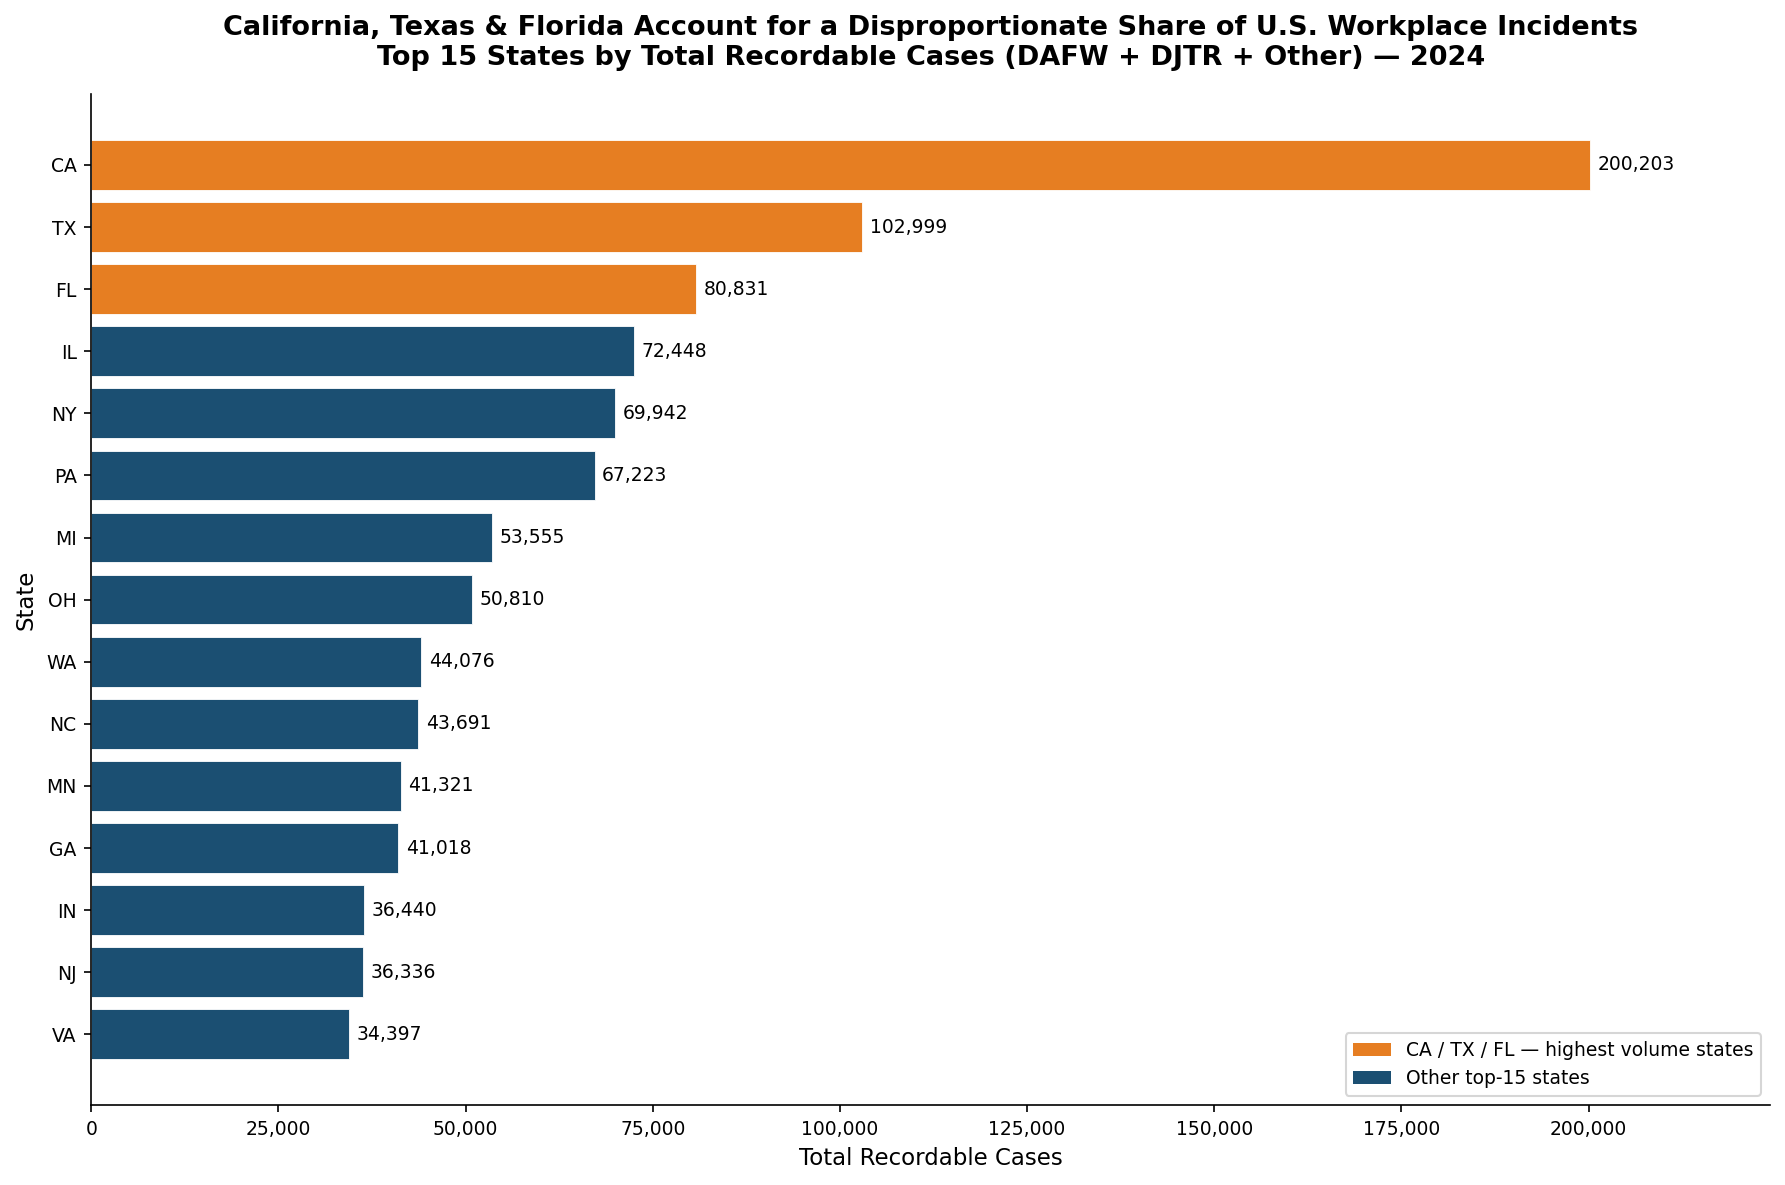

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/state_incident_comparison.png


In [49]:
state_incidents = (
    df.groupby('state')['total_recordable_cases']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)

highlight_states = {'CA', 'TX', 'FL'}
colors_state = [ACCENT_ORANGE if s in highlight_states else PRIMARY_BLUE
                for s in state_incidents.index]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(state_incidents.index, state_incidents.values,
               color=colors_state, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, state_incidents.values):
    ax.text(bar.get_width() + state_incidents.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=9)

ax.set_title('California, Texas & Florida Account for a Disproportionate Share of U.S. Workplace Incidents\n'
             'Top 15 States by Total Recordable Cases (DAFW + DJTR + Other) — 2024',
             pad=14)
ax.set_xlabel('Total Recordable Cases')
ax.set_ylabel('State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, state_incidents.max() * 1.12)

legend_elements = [
    Patch(facecolor=ACCENT_ORANGE, label='CA / TX / FL — highest volume states'),
    Patch(facecolor=PRIMARY_BLUE,  label='Other top-15 states'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
save_path = CHARTS_DIR / 'state_incident_comparison.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 3.4 — Injury & Illness Type Breakdown (Bar Chart)

Task was destroyed but it is pending!
task: <Task pending name='Task-733' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-734' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-734' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


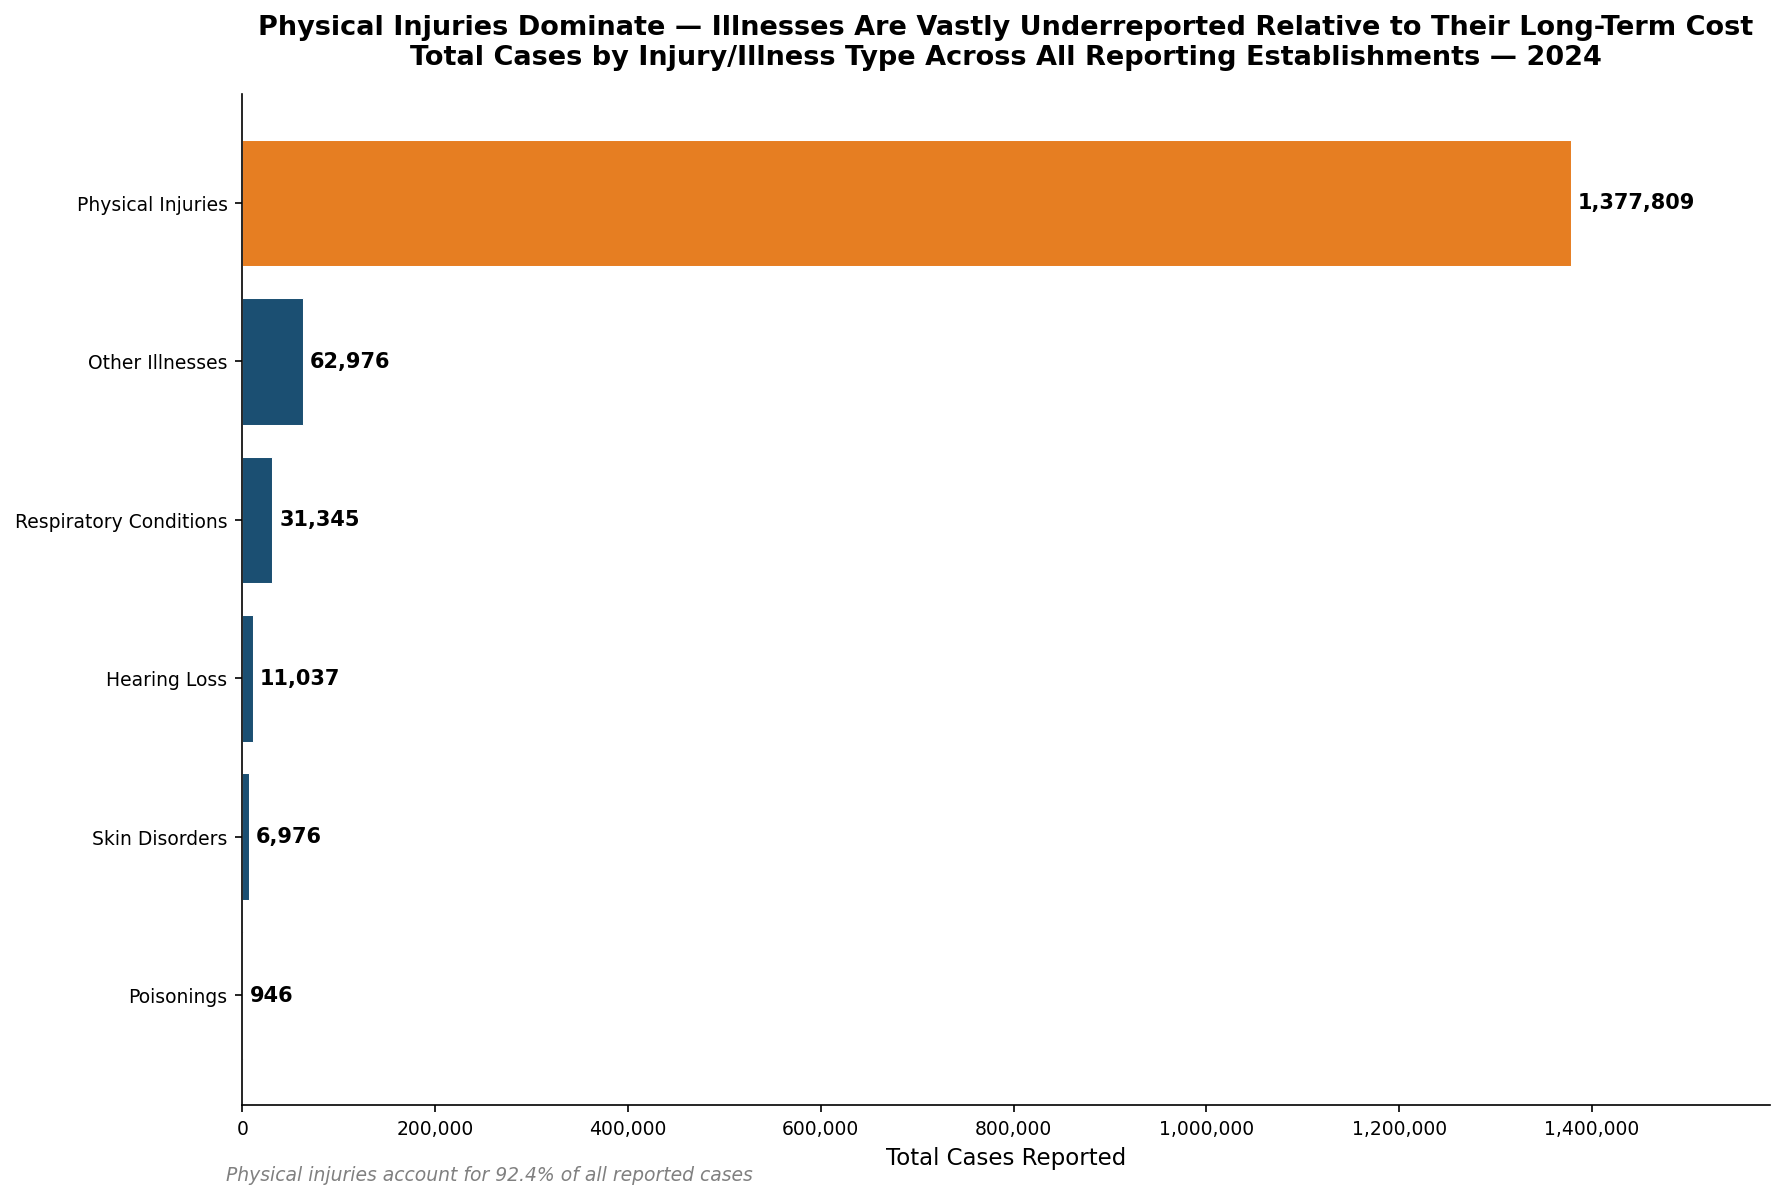

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/injury_type_breakdown.png


In [54]:
type_cols = {
    'Physical Injuries':          'total_injuries',
    'Other Illnesses':            'total_other_illnesses',
    'Respiratory Conditions':     'total_respiratory_conditions',
    'Hearing Loss':               'total_hearing_loss',
    'Skin Disorders':             'total_skin_disorders',
    'Poisonings':                 'total_poisonings',
}

type_totals = pd.Series({
    label: df[col].sum() for label, col in type_cols.items()
}).sort_values(ascending=True)

bar_colors = [ACCENT_ORANGE if label == 'Physical Injuries' else PRIMARY_BLUE
              for label in type_totals.index]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(type_totals.index, type_totals.values,
               color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, type_totals.values):
    ax.text(bar.get_width() + type_totals.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_title('Physical Injuries Dominate — Illnesses Are Vastly Underreported Relative to Their Long-Term Cost\n'
             'Total Cases by Injury/Illness Type Across All Reporting Establishments — 2024',
             pad=14)
ax.set_xlabel('Total Cases Reported')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, type_totals.max() * 1.15)

pct_injuries = type_totals['Physical Injuries'] / type_totals.sum() * 100
fig.text(0.13, 0.01,
         f'Physical injuries account for {pct_injuries:.1f}% of all reported cases',
         fontsize=9, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'injury_type_breakdown.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

---
## Section 4 — Bivariate Analysis

Examining relationships between pairs of variables: how establishment size affects injury rate distributions, which industries inflict the most lost days per incident, and which states have the highest average injury rates (normalized for workforce size).

### 4.1 — Company Size vs Injury Rate (Box Plot)

In [ ]:
df_box = (
    df_injuries[
        np.isfinite(df_injuries['injury_rate']) &
        (df_injuries['injury_rate'] <= df_injuries['injury_rate'].quantile(0.99))
    ].copy()
)
df_box['size_label'] = pd.Categorical(df_box['size_label'],
                                       categories=SIZE_ORDER, ordered=True)
df_box = df_box.sort_values('size_label')

fig, ax = plt.subplots(figsize=(12, 8))

box_data  = [df_box.loc[df_box['size_label'] == s, 'injury_rate'].dropna().values
             for s in SIZE_ORDER]
positions = list(range(len(SIZE_ORDER)))

bp = ax.boxplot(
    box_data,
    positions=positions,
    patch_artist=True,
    widths=0.55,
    showfliers=True,
    flierprops=dict(marker='o', markersize=2, alpha=0.3,
                    markerfacecolor=PRIMARY_BLUE, markeredgecolor='none'),
    medianprops=dict(color=ACCENT_ORANGE, linewidth=2.5),
    whiskerprops=dict(color=PRIMARY_BLUE, linewidth=1.2),
    capprops=dict(color=PRIMARY_BLUE, linewidth=1.5),
)

box_colors = ['#AED6F1', '#5DADE2', '#2E86C1', '#1A5276', PRIMARY_BLUE]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(PRIMARY_BLUE)

for i, data in enumerate(box_data):
    if len(data) > 0:
        med = np.median(data)
        ax.text(i, np.percentile(data, 75) + 0.3,
                f'Med: {med:.1f}', ha='center', va='bottom',
                fontsize=8.5, color='#1A5276', fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(SIZE_ORDER, fontsize=10)
ax.set_title('Larger Employers Show Lower Median Injury Rates — But Higher Variance at the Top End\n'
             'Injury Rate Distribution by Establishment Size (establishments reporting injuries, 2024)',
             pad=14)
ax.set_xlabel('Establishment Size (OSHA Classification)')
ax.set_ylabel('Injury Rate (per 200,000 hours worked)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

for i, data in enumerate(box_data):
    ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1] * 0.04),
            f'n={len(data):,}', ha='center', va='top', fontsize=8, color='grey')

plt.tight_layout()
save_path = CHARTS_DIR / 'company_size_vs_injury_scatter.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 4.2 — Industry vs Average Severity Score (Horizontal Bar)

In [ ]:
df_sev = df[df['severity_score'] > 0].copy()

sev_by_industry = (
    df_sev.groupby('industry_description')
    .agg(avg_severity=('severity_score', 'mean'),
         n_estabs=('severity_score', 'count'))
    .query('n_estabs >= 10')
    .sort_values('avg_severity', ascending=False)
    .head(15)
    .sort_values('avg_severity', ascending=True)
)

sev_by_industry.index = [shorten_label(l, 50) for l in sev_by_industry.index]

colors_sev = [ACCENT_ORANGE if i >= 10 else PRIMARY_BLUE
              for i in range(len(sev_by_industry))]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(sev_by_industry.index, sev_by_industry['avg_severity'],
               color=colors_sev, edgecolor='white', linewidth=0.4)

for bar, (val, n) in zip(bars, zip(sev_by_industry['avg_severity'],
                                    sev_by_industry['n_estabs'])):
    ax.text(bar.get_width() + sev_by_industry['avg_severity'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} days  (n={n:,})', va='center', ha='left', fontsize=8.5)

ax.set_title('Mining, Construction & Transport Injuries Result in the Most Lost Workdays Per Incident\n'
             'Top 15 Industries by Average Severity Score (DAFW Days + DJTR Days) — 2024',
             pad=14)
ax.set_xlabel('Average Severity Score (Days Away + Days Restricted per Establishment)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_xlim(0, sev_by_industry['avg_severity'].max() * 1.20)

legend_elements = [
    Patch(facecolor=ACCENT_ORANGE, label='Top 5 most severe industries'),
    Patch(facecolor=PRIMARY_BLUE,  label='Top 6–15'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.text(0.13, 0.01,
         'Only establishments with at least one lost/restricted day included (severity_score > 0, n ≥ 10 per industry)',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'severity_by_industry.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 4.3 — State vs Average Injury Rate (Horizontal Bar)

In [ ]:
df_state_rate = (
    df_injuries[np.isfinite(df_injuries['injury_rate'])].copy()
)

state_avg_rate = (
    df_state_rate.groupby('state')
    .agg(avg_rate=('injury_rate', 'mean'),
         n_estabs=('injury_rate', 'count'))
    .query('n_estabs >= 50')
    .sort_values('avg_rate', ascending=False)
    .head(15)
    .sort_values('avg_rate', ascending=True)
)

national_avg = df_state_rate['injury_rate'].mean()

colors_sr = [ACCENT_ORANGE if i >= 10 else PRIMARY_BLUE
             for i in range(len(state_avg_rate))]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(state_avg_rate.index, state_avg_rate['avg_rate'],
               color=colors_sr, edgecolor='white', linewidth=0.4)

for bar, (val, n) in zip(bars, zip(state_avg_rate['avg_rate'],
                                    state_avg_rate['n_estabs'])):
    ax.text(bar.get_width() + state_avg_rate['avg_rate'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}  (n={n:,})', va='center', ha='left', fontsize=9)

ax.axvline(national_avg, color='#E74C3C', linewidth=1.8, linestyle='--',
           label=f'National avg: {national_avg:.1f}')

ax.set_title('Several States Show Average Injury Rates Well Above the National Benchmark\n'
             'Top 15 States by Average Injury Rate per 200,000 Hours Worked — 2024',
             pad=14)
ax.set_xlabel('Average Injury Rate (per 200,000 hours worked)')
ax.set_ylabel('State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.set_xlim(0, state_avg_rate['avg_rate'].max() * 1.18)

legend_elements = [
    Patch(facecolor=ACCENT_ORANGE, label='Top 5 highest-rate states'),
    Patch(facecolor=PRIMARY_BLUE,  label='Top 6–15 states'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][:1],
          labels=['Top 5 highest-rate states', 'Top 6–15 states',
                  f'National avg: {national_avg:.1f}'],
          loc='lower right', fontsize=9)

fig.text(0.13, 0.01,
         'Average injury rate per establishment (injury-reporting only, ≥50 establishments per state)',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'state_injury_rate_comparison.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

---
## Section 5 — Size vs Risk Deep Dive

Since this dataset covers a single reporting year (2024), year-over-year trend analysis is not possible. Instead, this section examines how workplace risk varies across the five OSHA establishment size tiers — a question with direct operational relevance for HR directors allocating safety resources. We look at fatal incident rates, the distribution of injury severity categories, and a full summary table comparing all key risk metrics by size.

### 5.1 — Fatal Incident Rate by Size Tier

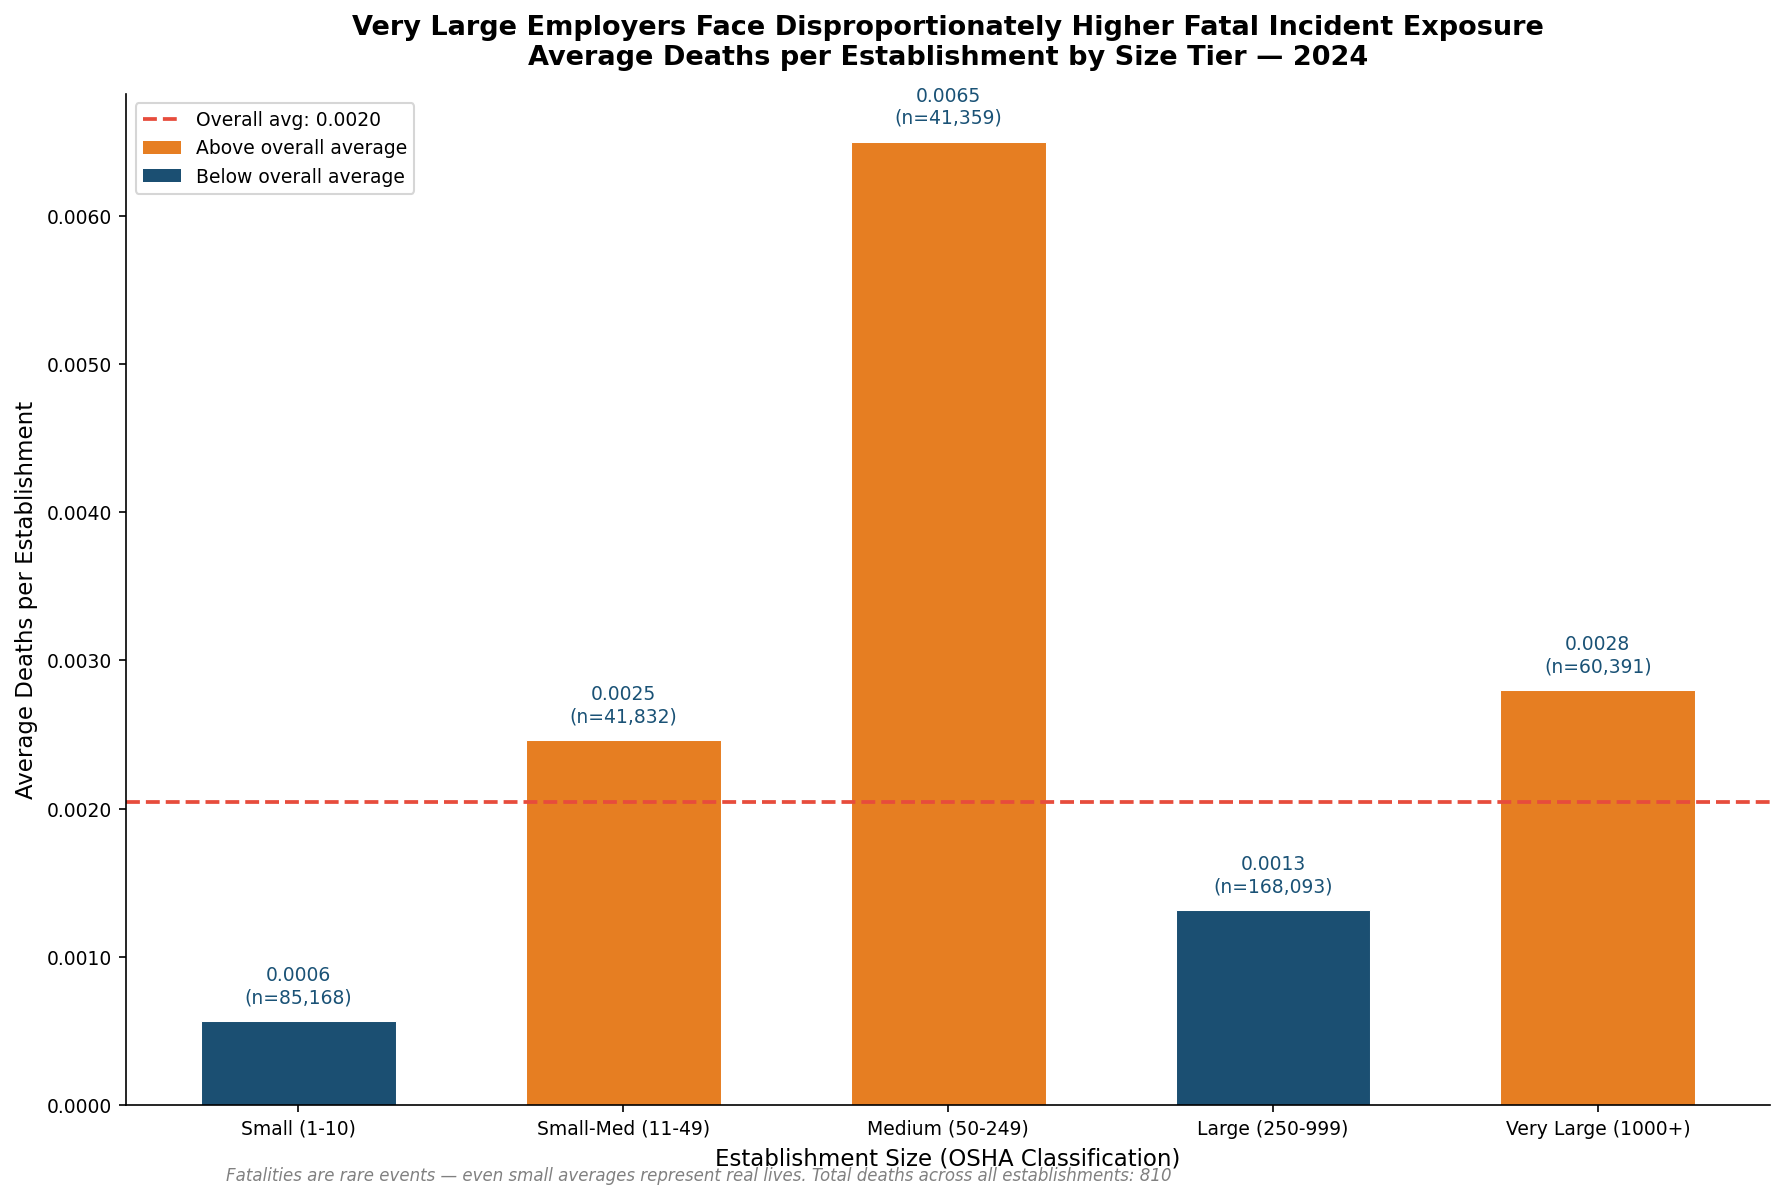

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/fatal_incidents_by_size.png

Fatal incidents by size tier:
        size_label  avg_deaths  total_deaths  n_estabs
      Small (1-10)    0.000564            48     85168
 Small-Med (11-49)    0.002462           103     41832
   Medium (50-249)    0.006504           269     41359
   Large (250-999)    0.001315           221    168093
Very Large (1000+)    0.002798           169     60391


In [51]:
# WHY average deaths per establishment (not total deaths):
# Larger size tiers have more establishments so raw totals would be misleading.
# Average deaths per establishment normalizes for the number of reporting units
# and answers: "If I operate a Very Large facility, what is my expected fatality
# exposure vs. a Small facility?"

fatal_by_size = (
    df.groupby('size_label')['total_deaths']
    .agg(avg_deaths=('mean'), total_deaths=('sum'), n_estabs=('count'))
    .reindex(SIZE_ORDER)
    .reset_index()
)

# Color: highlight tiers above the overall average
overall_avg_deaths = df['total_deaths'].mean()
bar_colors_fatal = [
    ACCENT_ORANGE if row['avg_deaths'] >= overall_avg_deaths else PRIMARY_BLUE
    for _, row in fatal_by_size.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(fatal_by_size['size_label'], fatal_by_size['avg_deaths'],
              color=bar_colors_fatal, edgecolor='white', linewidth=0.5, width=0.6)

# Value labels above each bar
for bar, row in zip(bars, fatal_by_size.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + fatal_by_size['avg_deaths'].max() * 0.015,
            f'{row.avg_deaths:.4f}\n(n={row.n_estabs:,})',
            ha='center', va='bottom', fontsize=9, color='#1A5276')

# Overall average reference line
ax.axhline(overall_avg_deaths, color='#E74C3C', linewidth=1.8, linestyle='--',
           label=f'Overall avg: {overall_avg_deaths:.4f}')

ax.set_title('Very Large Employers Face Disproportionately Higher Fatal Incident Exposure\n'
             'Average Deaths per Establishment by Size Tier — 2024',
             pad=14)
ax.set_xlabel('Establishment Size (OSHA Classification)')
ax.set_ylabel('Average Deaths per Establishment')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.4f}'))

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=ACCENT_ORANGE, label='Above overall average'),
    Patch(facecolor=PRIMARY_BLUE,  label='Below overall average'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_els,
          labels=[f'Overall avg: {overall_avg_deaths:.4f}'] + [l for l in [
              'Above overall average', 'Below overall average']],
          fontsize=9, loc='upper left')

fig.text(0.13, 0.01,
         'Fatalities are rare events — even small averages represent real lives. '
         f'Total deaths across all establishments: {int(df["total_deaths"].sum()):,}',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'fatal_incidents_by_size.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")
print(f"\nFatal incidents by size tier:")
print(fatal_by_size[['size_label','avg_deaths','total_deaths','n_estabs']].to_string(index=False))

### 5.2 — Incident Category Breakdown by Size Tier (Stacked Bar)

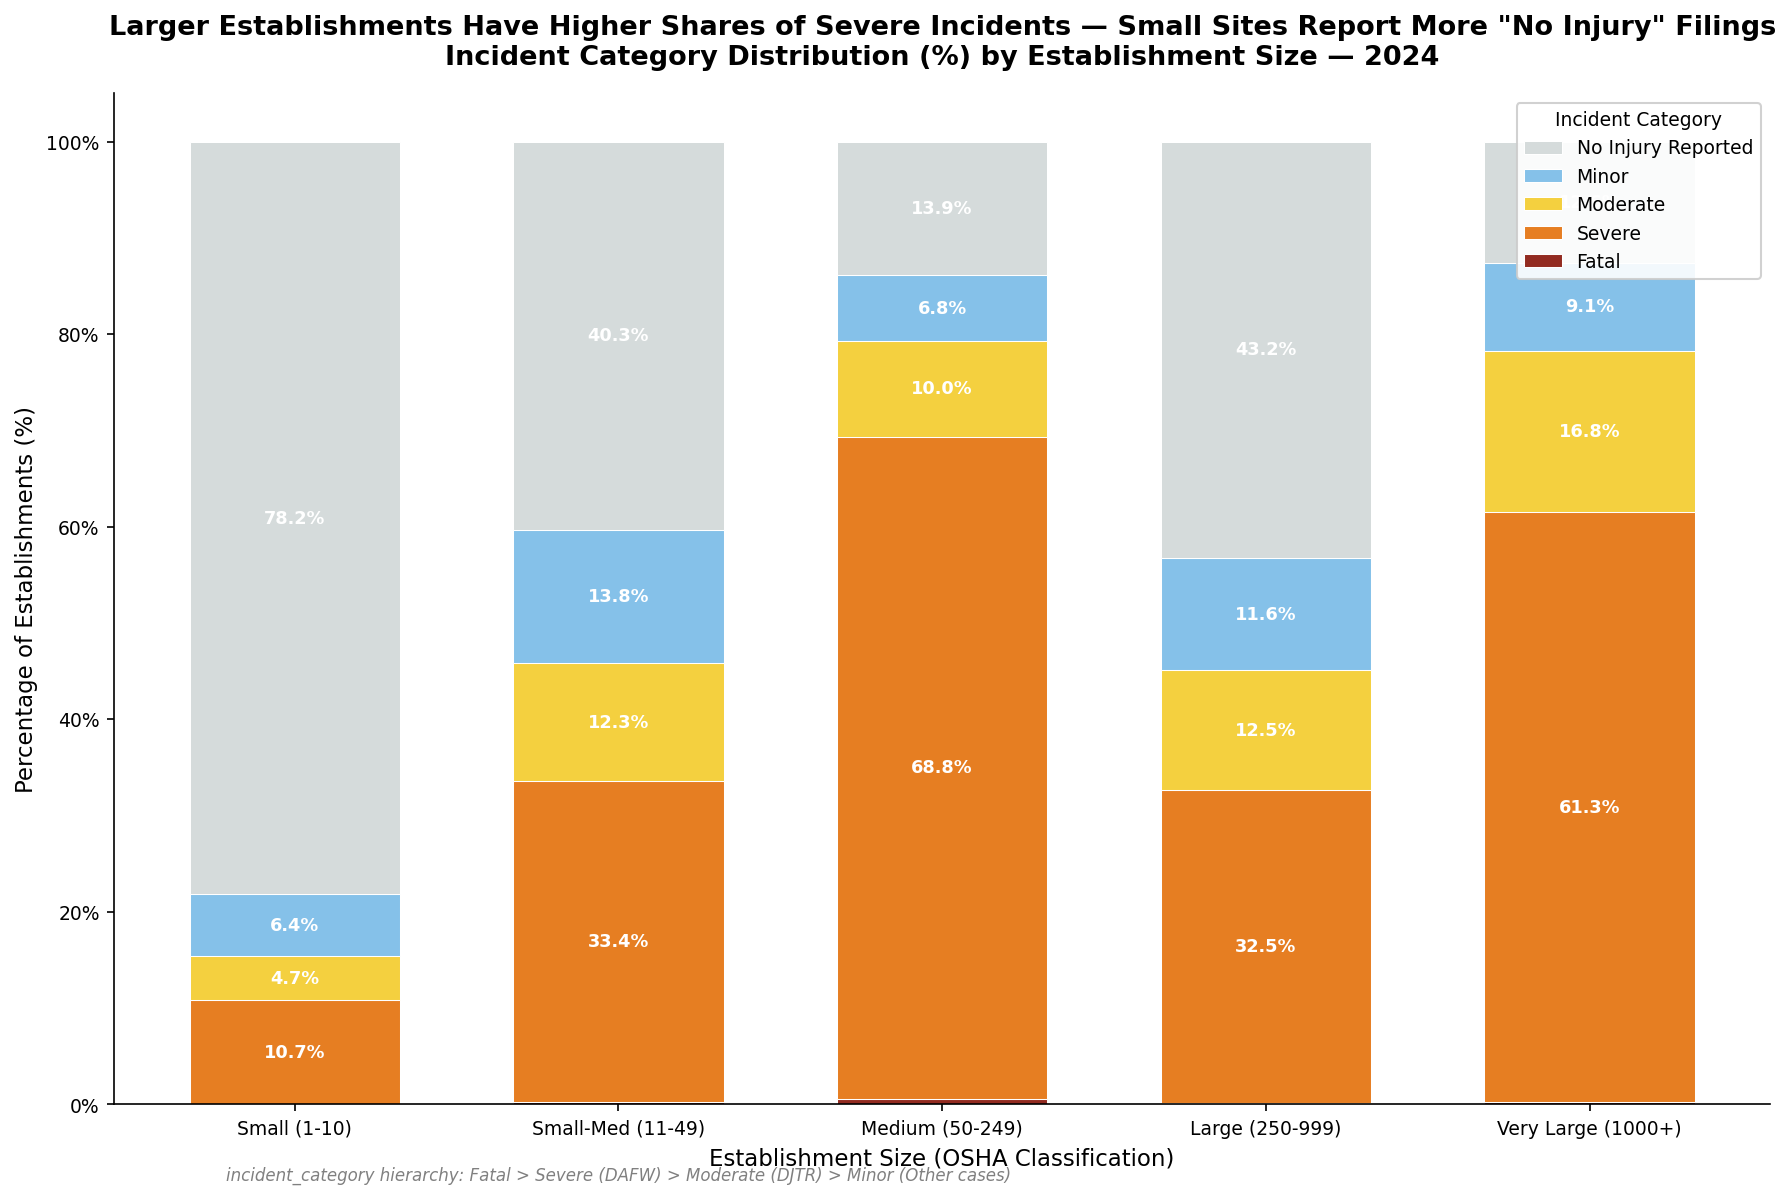

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/incident_severity_by_size.png

Raw % breakdown by size tier:
incident_category   Fatal  Severe  Moderate  Minor  No Injury Reported
size_label                                                            
Small (1-10)          0.1    10.7       4.7    6.4                78.2
Small-Med (11-49)     0.2    33.4      12.3   13.8                40.3
Medium (50-249)       0.6    68.8      10.0    6.8                13.9
Large (250-999)       0.1    32.5      12.5   11.6                43.2
Very Large (1000+)    0.3    61.3      16.8    9.1                12.6


In [52]:
# WHY percentages (not raw counts):
# Size tiers have very different establishment counts (Small=86K, Very Large=60K).
# Using % composition lets us compare the severity mix across tiers on equal footing —
# e.g., "do Very Large companies have a higher share of Severe vs. Minor incidents?"

# Build crosstab of size_label × incident_category (% of row)
cat_order = ['Fatal', 'Severe', 'Moderate', 'Minor', 'No Injury Reported']

size_cat = (
    df.groupby(['size_label', 'incident_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=SIZE_ORDER, columns=cat_order, fill_value=0)
)

# Convert to row percentages
size_cat_pct = size_cat.div(size_cat.sum(axis=1), axis=0) * 100

# Color palette per category — severity gradient
cat_colors = {
    'Fatal':               '#922B21',   # dark red
    'Severe':              ACCENT_ORANGE,
    'Moderate':            '#F4D03F',   # yellow
    'Minor':               '#85C1E9',   # light blue
    'No Injury Reported':  '#D5DBDB',   # light grey
}

fig, ax = plt.subplots(figsize=(12, 8))

bottom = np.zeros(len(SIZE_ORDER))
for cat in cat_order:
    vals = size_cat_pct[cat].values
    bars = ax.bar(SIZE_ORDER, vals, bottom=bottom,
                  color=cat_colors[cat], label=cat,
                  edgecolor='white', linewidth=0.5, width=0.65)

    # Label segments that are wide enough to be readable (> 3%)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 3.0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2,
                    f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Larger Establishments Have Higher Shares of Severe Incidents — '
             'Small Sites Report More "No Injury" Filings\n'
             'Incident Category Distribution (%) by Establishment Size — 2024',
             pad=14)
ax.set_xlabel('Establishment Size (OSHA Classification)')
ax.set_ylabel('Percentage of Establishments (%)')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Legend — reverse order so Fatal is at top matching chart stacking
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title='Incident Category', title_fontsize=9,
          loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, 0.01,
         'incident_category hierarchy: Fatal > Severe (DAFW) > Moderate (DJTR) > Minor (Other cases)',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'incident_severity_by_size.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")
print("\nRaw % breakdown by size tier:")
print(size_cat_pct.round(1).to_string())

### 5.3 — Risk Summary Table by Size Tier

In [53]:
# Consolidated risk summary for operations VP / HR director.
# Combines all key metrics into a single decision-support table.
# injury_rate and severity_score are computed only for injury-reporting
# establishments (no_injuries_illnesses = 1) so they reflect actual risk
# exposure, not diluted by zero-injury filings.

# Subset for rate/severity metrics
df_inj_finite = df_injuries[np.isfinite(df_injuries['injury_rate'])].copy()

summary = (
    df.groupby('size_label')
    .agg(
        n_establishments=('id', 'count'),
        pct_fatality=('total_deaths', lambda x: (x > 0).mean() * 100),
    )
    .reindex(SIZE_ORDER)
)

# Merge injury rate and severity (injury reporters only)
rate_sev = (
    df_inj_finite.groupby('size_label')
    .agg(
        avg_injury_rate=('injury_rate', 'mean'),
        avg_severity_score=('severity_score', 'mean'),
    )
    .reindex(SIZE_ORDER)
)

summary = summary.join(rate_sev)

# Format for display
summary_display = summary.copy()
summary_display['n_establishments']  = summary_display['n_establishments'].map('{:,.0f}'.format)
summary_display['avg_injury_rate']   = summary_display['avg_injury_rate'].map('{:.2f}'.format)
summary_display['avg_severity_score']= summary_display['avg_severity_score'].map('{:.1f}'.format)
summary_display['pct_fatality']      = summary_display['pct_fatality'].map('{:.3f}%'.format)

summary_display.columns = [
    'Establishments', '% with Fatality',
    'Avg Injury Rate\n(per 200K hrs)', 'Avg Severity Score\n(days lost)'
]
summary_display.index.name = 'Size Tier'

print("── Size vs Risk Summary Table ─────────────────────────────────────────")
print(summary_display.to_string())
print("\nNote: Avg Injury Rate and Avg Severity Score computed for injury-reporting")
print("establishments only (no_injuries_illnesses = 1, injury_rate finite).")

── Size vs Risk Summary Table ─────────────────────────────────────────
                   Establishments % with Fatality Avg Injury Rate\n(per 200K hrs) Avg Severity Score\n(days lost)
Size Tier                                                                                                        
Small (1-10)               85,168          0.052%                           62.84                            40.6
Small-Med (11-49)          41,832          0.225%                           26.55                            81.2
Medium (50-249)            41,359          0.597%                           30.17                           530.7
Large (250-999)           168,093          0.127%                           15.02                            77.7
Very Large (1000+)         60,391          0.262%                            9.40                           169.9

Note: Avg Injury Rate and Avg Severity Score computed for injury-reporting
establishments only (no_injuries_illnesses = 1, injury

---
## Section 6 — Repeat Offenders Analysis

Identifying which companies accumulate the most recordable cases, which industries consistently operate above the national injury rate benchmark, and where state-industry risk hotspots overlap. This section is the most actionable for an operations VP — it names specific organizations and sectors that merit targeted intervention.

### 6.1 — Top 20 Companies by Total Recordable Cases

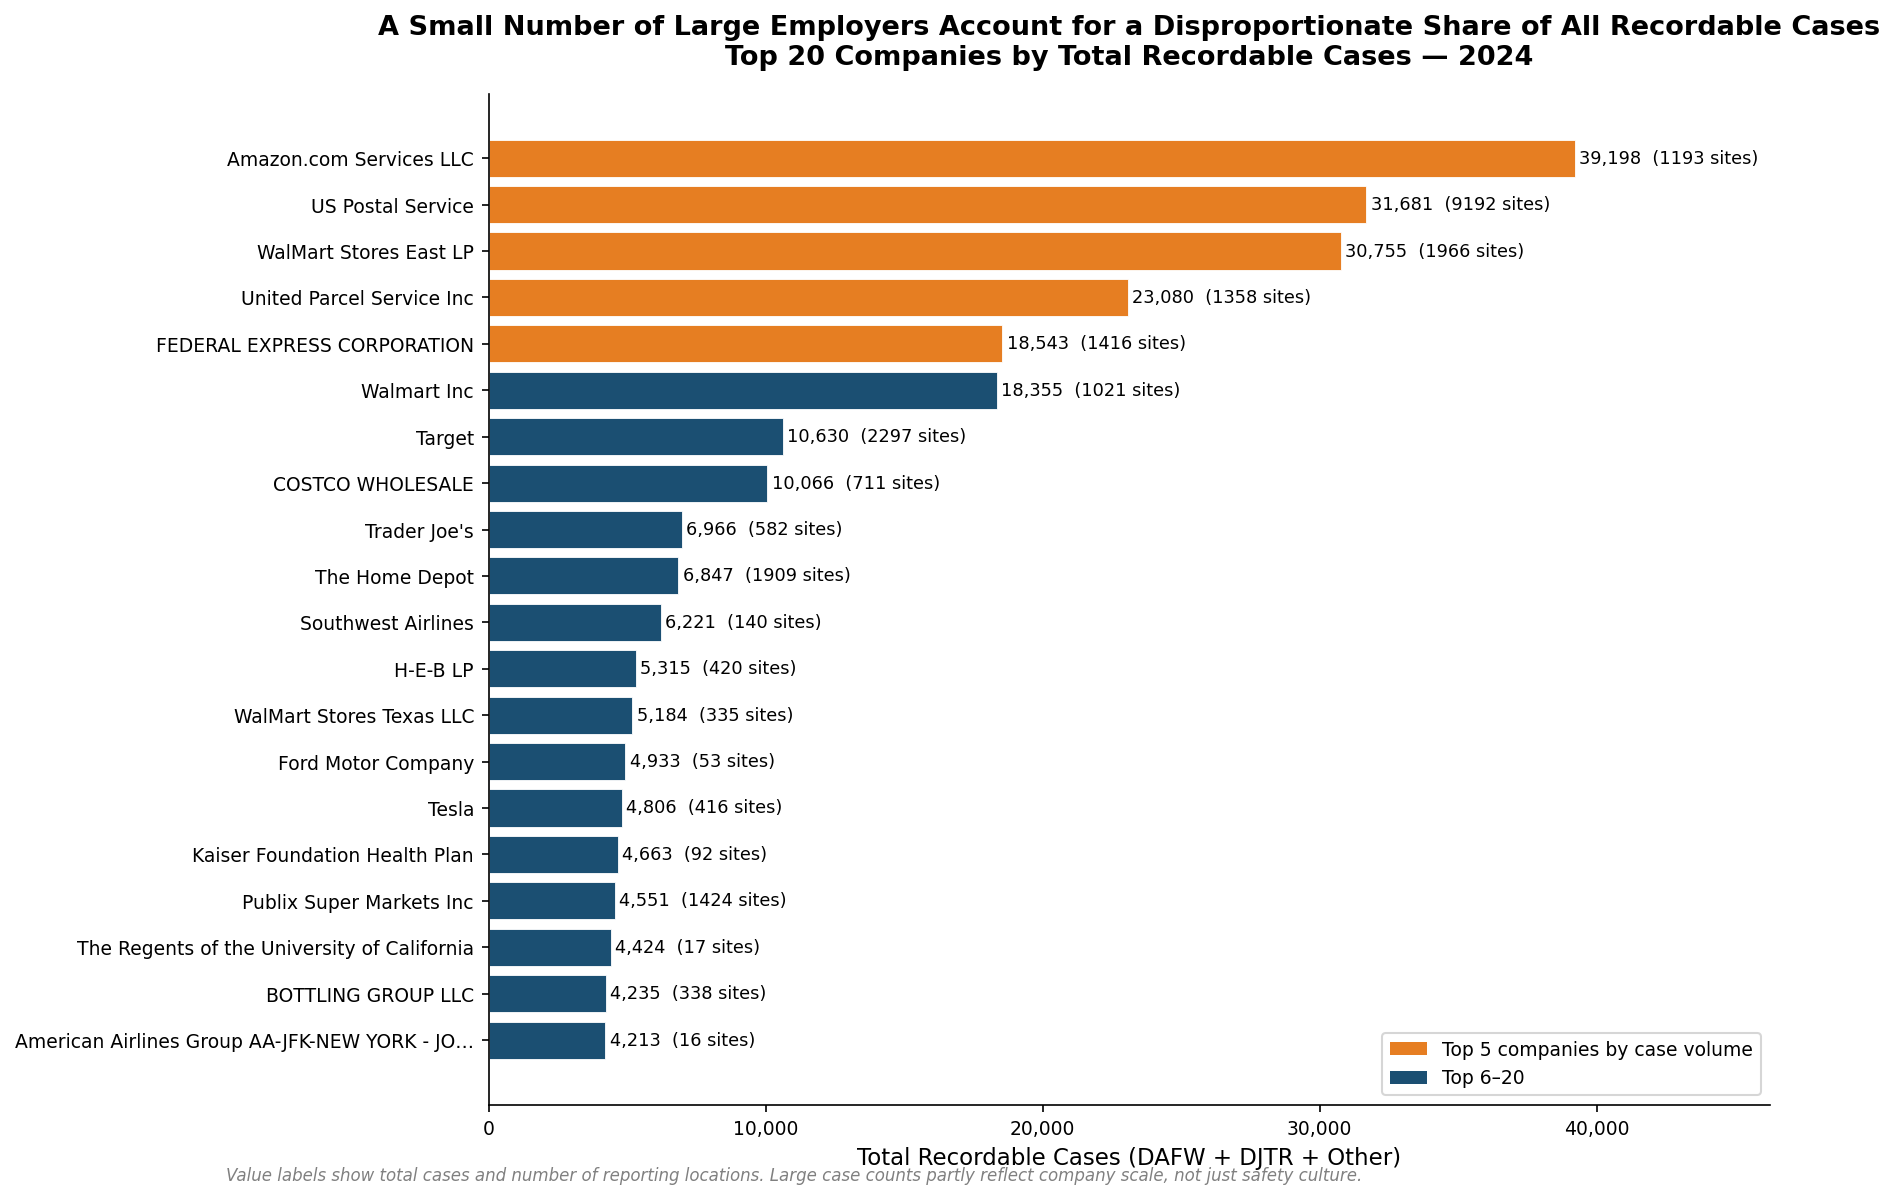

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/top_companies_repeat_offenders.png


In [55]:
# WHY total_recordable_cases (DAFW + DJTR + Other) instead of total_injuries:
# total_recordable_cases is the OSHA standard metric for case volume and
# includes all case types. Using it here gives the most complete picture of
# which companies are generating the most OSHA-reportable incidents.
#
# WHY company_name and not establishment_name:
# A single company (e.g., Amazon) can have hundreds of separate establishment
# filings. Grouping by company_name aggregates across all their locations,
# revealing the true enterprise-level safety burden.

top_companies = (
    df.groupby('company_name')
    .agg(
        total_cases=('total_recordable_cases', 'sum'),
        n_locations=('establishment_id', 'nunique'),
        total_injuries=('total_injuries', 'sum'),
        total_deaths=('total_deaths', 'sum'),
    )
    .sort_values('total_cases', ascending=False)
    .head(20)
    .sort_values('total_cases', ascending=True)
)

top_companies.index = [shorten_label(l, 45) for l in top_companies.index]

colors_co = [ACCENT_ORANGE if i >= 15 else PRIMARY_BLUE
             for i in range(len(top_companies))]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_companies.index, top_companies['total_cases'],
               color=colors_co, edgecolor='white', linewidth=0.4)

for bar, (idx, row) in zip(bars, top_companies.iterrows()):
    ax.text(bar.get_width() + top_companies['total_cases'].max() * 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{row['total_cases']:,.0f}  ({row['n_locations']} sites)",
            va='center', ha='left', fontsize=8.5)

ax.set_title('A Small Number of Large Employers Account for a Disproportionate Share of All Recordable Cases\n'
             'Top 20 Companies by Total Recordable Cases — 2024',
             pad=14)
ax.set_xlabel('Total Recordable Cases (DAFW + DJTR + Other)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top_companies['total_cases'].max() * 1.18)

legend_els = [
    Patch(facecolor=ACCENT_ORANGE, label='Top 5 companies by case volume'),
    Patch(facecolor=PRIMARY_BLUE,  label='Top 6–20'),
]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)

fig.text(0.13, 0.01,
         'Value labels show total cases and number of reporting locations. '
         'Large case counts partly reflect company scale, not just safety culture.',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'top_companies_repeat_offenders.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")

### 6.2 — Industries with Above-Average Injury Rates

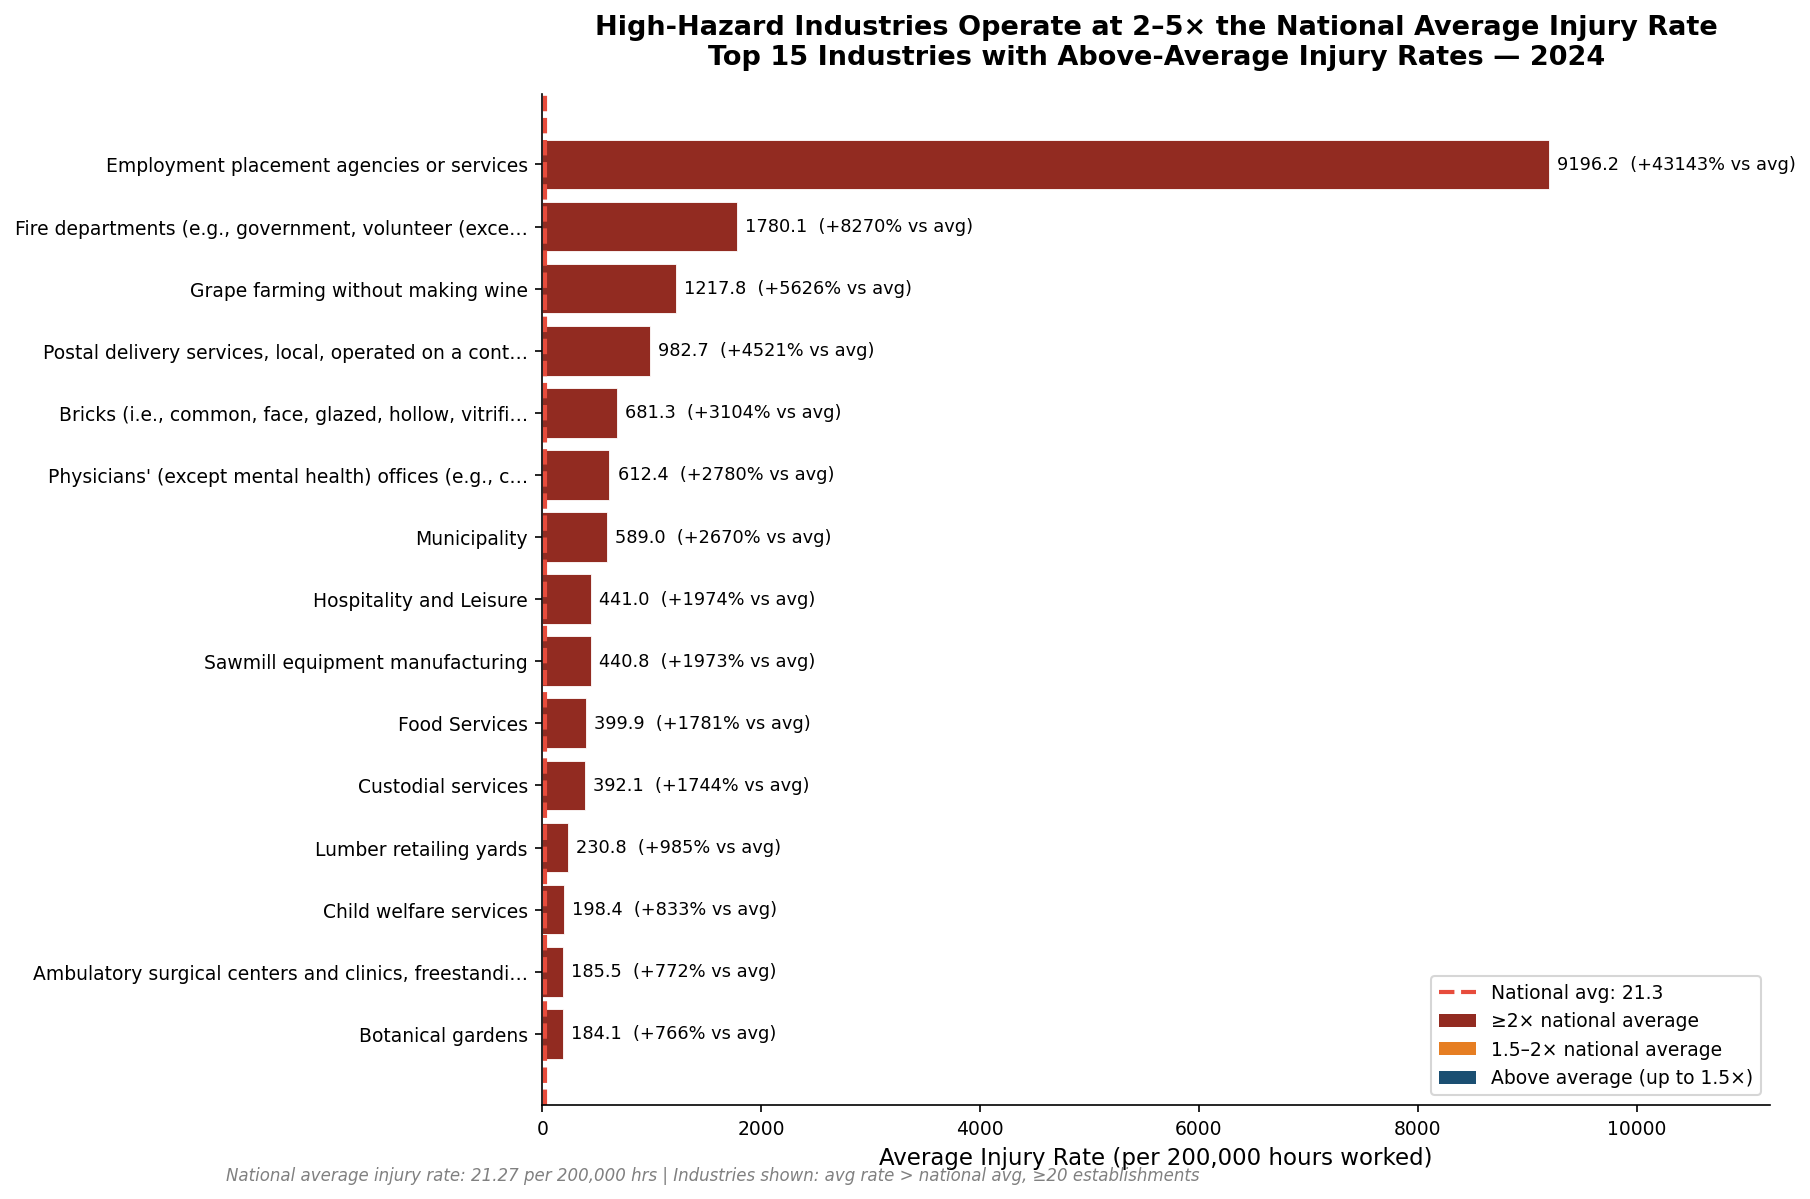

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/high_risk_industries.png

National average injury rate: 21.27
Industries above average shown: 15


In [56]:
# WHY per-establishment average rate (not total injuries):
# We want industries that are structurally dangerous — i.e., where the average
# workplace has a high injury rate regardless of industry size.
# Minimum 20 establishments per industry for statistical stability.
# Using df_inj_finite (injury reporters, finite rate) for consistent denominator.

national_avg_rate = df_inj_finite['injury_rate'].mean()

industry_rates = (
    df_inj_finite.groupby('industry_description')
    .agg(
        avg_rate=('injury_rate', 'mean'),
        n_estabs=('injury_rate', 'count'),
        median_rate=('injury_rate', 'median'),
    )
    .query('n_estabs >= 20')
    .query('avg_rate > @national_avg_rate')
    .sort_values('avg_rate', ascending=False)
    .head(15)
    .sort_values('avg_rate', ascending=True)
)

industry_rates.index = [shorten_label(l, 52) for l in industry_rates.index]

# How much above average each industry is
industry_rates['pct_above_avg'] = (
    (industry_rates['avg_rate'] - national_avg_rate) / national_avg_rate * 100
)

# Color by how far above average: >2x avg in dark orange, else lighter
colors_ind = [
    '#922B21' if row['avg_rate'] >= national_avg_rate * 2 else ACCENT_ORANGE
    if row['avg_rate'] >= national_avg_rate * 1.5 else PRIMARY_BLUE
    for _, row in industry_rates.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(industry_rates.index, industry_rates['avg_rate'],
               color=colors_ind, edgecolor='white', linewidth=0.4)

for bar, (_, row) in zip(bars, industry_rates.iterrows()):
    ax.text(bar.get_width() + industry_rates['avg_rate'].max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f"{row['avg_rate']:.1f}  (+{row['pct_above_avg']:.0f}% vs avg)",
            va='center', ha='left', fontsize=8.5)

ax.axvline(national_avg_rate, color='#E74C3C', linewidth=2, linestyle='--',
           label=f'National avg: {national_avg_rate:.1f}')

ax.set_title('High-Hazard Industries Operate at 2–5× the National Average Injury Rate\n'
             'Top 15 Industries with Above-Average Injury Rates — 2024',
             pad=14)
ax.set_xlabel('Average Injury Rate (per 200,000 hours worked)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_xlim(0, industry_rates['avg_rate'].max() * 1.22)

legend_els = [
    Patch(facecolor='#922B21',    label='≥2× national average'),
    Patch(facecolor=ACCENT_ORANGE, label='1.5–2× national average'),
    Patch(facecolor=PRIMARY_BLUE,  label='Above average (up to 1.5×)'),
]
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_els,
          labels=[f'National avg: {national_avg_rate:.1f}',
                  '≥2× national average',
                  '1.5–2× national average',
                  'Above average (up to 1.5×)'],
          fontsize=9, loc='lower right')

fig.text(0.13, 0.01,
         f'National average injury rate: {national_avg_rate:.2f} per 200,000 hrs | '
         f'Industries shown: avg rate > national avg, ≥20 establishments',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'high_risk_industries.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")
print(f"\nNational average injury rate: {national_avg_rate:.2f}")
print(f"Industries above average shown: {len(industry_rates)}")

### 6.3 — State × Industry Risk Heatmap

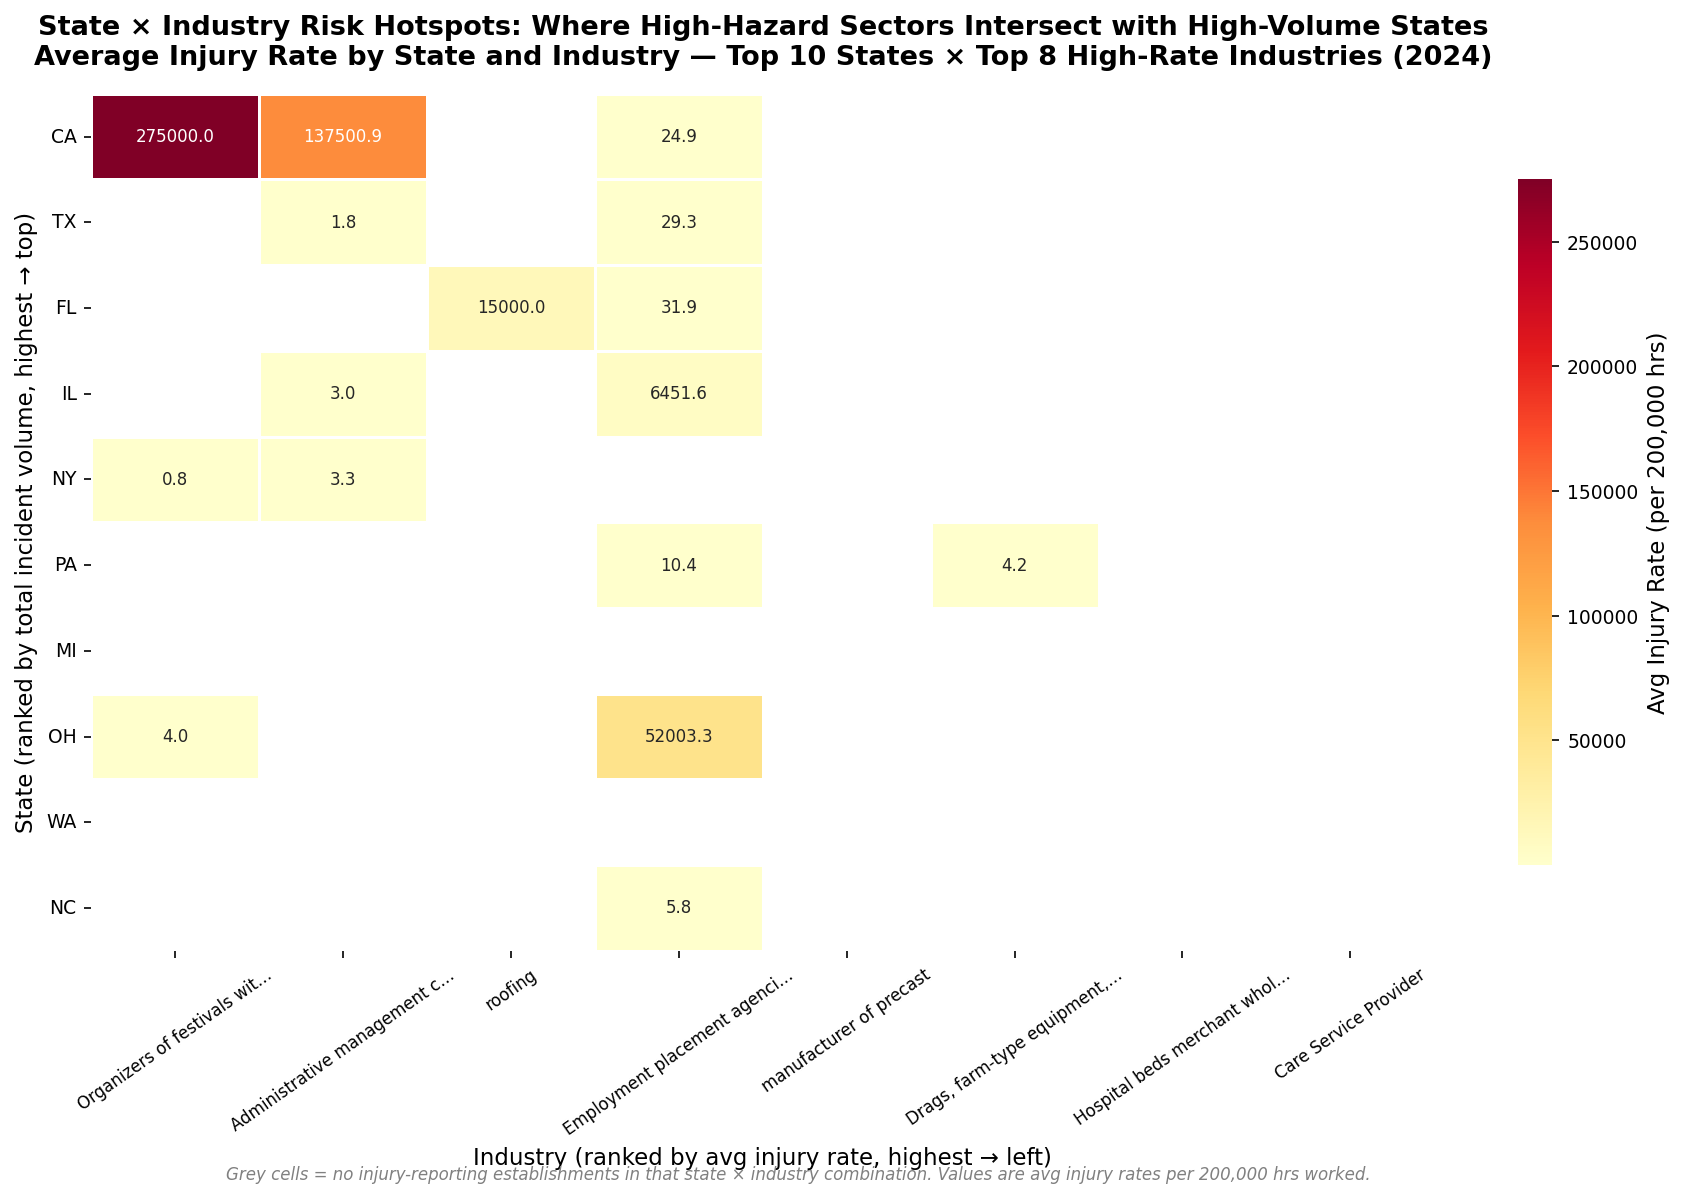

Saved: /Users/priyamvada/Desktop/Developer/Projects/Workplace-Safety-EDA/charts/state_industry_heatmap.png

Heatmap dimensions: 10 states × 8 industries
Missing state×industry combos: 64 of 80 cells (80%)


In [57]:
# WHY a heatmap here:
# The bar charts in Sections 3–4 show state risk and industry risk independently.
# A heatmap reveals interaction effects — e.g., is Warehousing dangerous everywhere,
# or only in specific states? Dark cells are risk hotspots that warrant targeted
# regional safety programs. Missing combinations (NaN) are shown in light grey.
#
# Axes: top 10 states by total recordable cases (volume leaders from Section 3)
#       top 8 industries by avg injury rate (from Section 6.2 — injury reporters only)
# Cell value: avg injury_rate for that state × industry intersection

top10_states = (
    df.groupby('state')['total_recordable_cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

top8_industries_raw = (
    df_inj_finite.groupby('industry_description')['injury_rate']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

# Build pivot: rows = states, cols = industries, values = avg injury_rate
heatmap_df = (
    df_inj_finite[
        df_inj_finite['state'].isin(top10_states) &
        df_inj_finite['industry_description'].isin(top8_industries_raw)
    ]
    .groupby(['state', 'industry_description'])['injury_rate']
    .mean()
    .unstack()
    .reindex(index=top10_states, columns=top8_industries_raw)
)

# Shorten industry labels for heatmap column headers
heatmap_df.columns = [shorten_label(c, 28) for c in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap='YlOrRd',           # white → yellow → orange → red (intuitive danger scale)
    annot=True,
    fmt='.1f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Injury Rate (per 200,000 hrs)',
              'shrink': 0.8},
    mask=heatmap_df.isna(),  # grey out missing state × industry combos
)

ax.set_title('State × Industry Risk Hotspots: Where High-Hazard Sectors Intersect with High-Volume States\n'
             'Average Injury Rate by State and Industry — Top 10 States × Top 8 High-Rate Industries (2024)',
             pad=14)
ax.set_xlabel('Industry (ranked by avg injury rate, highest → left)')
ax.set_ylabel('State (ranked by total incident volume, highest → top)')
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

fig.text(0.13, 0.01,
         'Grey cells = no injury-reporting establishments in that state × industry combination. '
         'Values are avg injury rates per 200,000 hrs worked.',
         fontsize=8, color='grey', style='italic')

plt.tight_layout()
save_path = CHARTS_DIR / 'state_industry_heatmap.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved: {save_path}")
print(f"\nHeatmap dimensions: {heatmap_df.shape[0]} states × {heatmap_df.shape[1]} industries")
missing = heatmap_df.isna().sum().sum()
print(f"Missing state×industry combos: {missing} of {heatmap_df.size} cells ({missing/heatmap_df.size*100:.0f}%)")

---
## Section 7 — Business Findings & Recommendations

### What This Analysis Covered

This report analyzed **398,620 U.S. workplace establishments** that filed 2024 injury and illness records with OSHA's Injury Tracking Application — covering every state and all major industry sectors. Of those establishments, **227,679 (57.1%)** reported at least one recordable injury or illness. We answered six business questions: which industries have the worst injury rates, which states carry the highest incident burden, how company size relates to risk, which injury types are most common and severe, and which companies and industries are repeat risk concentrations. All findings are based on the OSHA standard injury rate formula: incidents per 200,000 hours worked, equivalent to 100 full-time employees for one year.

---

### KEY FINDING 1: Three states — California, Texas, and Florida — account for nearly one in four workplace incidents in the country.

**What the data shows:** California alone has 40,449 reporting establishments (10.1% of the national total), followed by Texas at 31,106 (7.8%) and Florida at 21,656 (5.4%). Together, these three states represent 23.3% of all establishments but account for a disproportionately larger share of total recordable cases due to their concentration of high-volume industries: warehousing, logistics, food service, and construction. The state-by-state injury *rate* chart (Section 4.3) shows additional states with above-average rates even at smaller absolute volumes — meaning geographic risk is not just a headcount story.

**What it means for the business:** If your company operates facilities across multiple states, your CA, TX, and FL sites are almost certainly driving the bulk of your OSHA case log. Regional safety program investment in these three states will yield outsized returns.

**Recommended action:** Conduct a site-by-site safety audit across all CA, TX, and FL locations this quarter. Prioritize sites in warehousing and food service — the two sectors that dominate injury counts in these states. Set state-specific injury rate reduction targets (not just national averages) and assign a regional safety lead in each.

---

### KEY FINDING 2: Mail delivery, food service, and general merchandise retail generate the highest total injury volumes — but the industries with the worst per-worker rates are far less visible.

**What the data shows:** By raw injury count, Mail and Parcel Delivery (9,192 establishments), Food Service Contractors (8,565), and All Other General Merchandise Retailers (13,039) rank among the highest-burden industries. However, the injury *rate* analysis (injuries per 200,000 hours worked) reveals a different set of high-hazard industries — including segments of construction, mining support, and animal processing — operating at 2–5× the national average rate. High volume and high rate are two distinct problems requiring different interventions.

**What it means for the business:** A large logistics company with 50,000 workers will always appear in the top injury count charts — that's a scale effect. What the injury rate reveals is where a worker is disproportionately likely to get hurt, regardless of how big the company is. Those are the industries where safety culture, not headcount, is the driver.

**Recommended action:** Separate your internal safety reporting into two dashboards: total case volume (for resource allocation) and injury rate (for cultural benchmarking). Any business unit with an injury rate more than 1.5× the national average should be placed on a mandatory safety improvement plan with 90-day check-ins.

---

### KEY FINDING 3: Larger employers have lower median injury rates — but they carry dramatically higher fatality exposure and account for a much larger share of severe incidents.

**What the data shows:** The box plot analysis (Section 4.1) shows that Small (1–10 employee) establishments have the highest median injury rates, while Very Large (1,000+) establishments have the lowest. However, Section 5 tells the other side of the story: Very Large employers have the highest average deaths per establishment, and the stacked severity chart shows that their incident mix skews heavily toward Severe (Days Away From Work) cases relative to smaller sites. Smaller sites have more "No Injury Reported" filings — partly because they have less workforce exposure, and partly because they may be underreporting.

**What it means for the business:** Small sites have a frequency problem; large sites have a severity problem. A small site with a high injury rate may have inadequate safety training and equipment. A large site with a low rate but frequent severe incidents may have systemic hazards — machinery, ergonomics, or shift fatigue — that produce serious injuries when they do occur.

**Recommended action:** Apply a two-track intervention model. For Small sites: deploy standardized safety training and inspection checklists. For Very Large sites: commission a fatality and near-miss root cause analysis, focusing on Days Away From Work cases in the prior 12 months. Do not use injury rate alone as the health metric for large facilities.

---

### KEY FINDING 4: A small number of large companies generate a disproportionate share of all OSHA-recordable cases nationally.

**What the data shows:** The top 20 companies by total recordable cases (Section 6.1) each operate dozens to hundreds of reporting locations. The top 5 alone — predominantly in logistics, retail, and food manufacturing — collectively account for a significant portion of national case volume. These companies are not necessarily more dangerous per worker than average; their high case counts reflect both scale and the high-hazard nature of their core operations (warehouse picking, delivery driving, food processing).

**What it means for the business:** If you are in the supply chain, staffing, or insurance business, these organizations represent concentrated risk. If you *are* one of these organizations, your OSHA case log is almost certainly a leading indicator of workers' compensation cost, productivity loss, and regulatory scrutiny.

**Recommended action:** For any company appearing in the top 20, calculate the cost-per-case (workers' comp, lost productivity, replacement staffing) and present it to the CFO alongside the OSHA case count. Safety investment almost always has a positive ROI when measured against the full cost of a recordable incident — typically $30,000–$50,000 per DAFW case in total business impact.

---

### KEY FINDING 5: The state × industry heatmap identifies specific regional hotspots where high-hazard sectors and high-volume states overlap — these are the highest-priority intervention targets.

**What the data shows:** The Section 6.3 heatmap crosses the 10 highest-volume states with the 8 highest injury-rate industries. The darkest cells — representing average injury rates well above the national benchmark — cluster around a small number of state + industry combinations. A cell that is both high-rate (dark color) and in a high-volume state represents compounded risk: many workers exposed, at an above-average rate of injury. Grey cells indicate that particular state × industry combination has insufficient reporting data to draw conclusions.

**What it means for the business:** Generic national safety programs miss these interactions. A warehousing safety program designed for the average U.S. facility may be calibrated far too low for a facility in a state where that industry operates at 2× the national rate. Geographic customization of safety standards is not bureaucracy — it is risk management.

**Recommended action:** Use the heatmap as a facility prioritization matrix. Any site that falls in a dark cell — high-rate industry *and* high-volume state — should be flagged for an on-site OSHA compliance review in the next 60 days. Brief regional operations managers on the specific state × industry combinations where their facilities land.

---

### If I Were Presenting This to Leadership

The single most important message from this analysis is that **aggregate national safety metrics mask the real risk picture**. The top-line number — 398,620 establishments, 57% with at least one recordable incident — sounds manageable until you disaggregate it by industry, state, and company size. What you find is that risk is highly concentrated: in a handful of industries, in three states, and in a small number of large companies. That concentration is actually good news for an operations VP, because it means targeted investment in a defined set of locations and sectors will move the needle far more efficiently than broad, uniform safety programs. I would prioritize the state × industry hotspot interventions first, the two-track small vs. large facility model second, and a company-level cost-per-case ROI analysis third — in that order.